# Universal PFN for Isotope Mixing Models

This notebook trains a single "foundation" PFN that can dynamically handle varying dataset sizes:
* Observations ($N$): Variable (e.g., 1 to 1000+)
* Tracers/Isotopes ($J$): 1 to 4
* Sources ($K$): 2 to 10

It uses padding (filling unused dimensions with zeros) and masking (telling the model which dimensions are real vs padded) to learn a generalized inference algorithm.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 1. Dynamic Batched Simulator with Padding & Masking
This generator creates completely random sizes for every batch, simulates the data, and then pads everything to the maximum limits.

In [3]:
# Cell 2
MAX_J = 4
MAX_K = 10

def simulate_universal_batch(batch_size, device='cpu'):
    # 1. Randomize dimensions for THIS specific batch
    N = torch.randint(5, 100, (1,)).item()
    J = torch.randint(1, MAX_J + 1, (1,)).item()
    K = torch.randint(2, MAX_K + 1, (1,)).item()

    # 2. Simulate raw data
    q = torch.rand(batch_size, K, J, device=device) * 0.8 + 0.01
    s_mean = torch.randn(batch_size, K, J, device=device) * 15.0
    c_mean = torch.randn(batch_size, K, J, device=device) * 3.0
    s_sd = torch.rand(batch_size, K, J, device=device) * 2.5 + 0.1
    c_sd = torch.rand(batch_size, K, J, device=device) * 1.5 + 0.1
    
    mu_f = torch.zeros(batch_size, K, device=device)
    sigma_f = torch.ones(batch_size, K, device=device) 
    sigma_shape = torch.ones(batch_size, J, device=device) * 2.0
    sigma_rate = torch.ones(batch_size, J, device=device) * 1.0

    # Generative process
    f = torch.randn(batch_size, K, device=device) * sigma_f + mu_f
    expf = torch.exp(f)
    p = expf / torch.sum(expf, dim=1, keepdim=True) 
    
    gamma_dist = torch.distributions.Gamma(sigma_shape, sigma_rate)
    sigma = 0.001 + gamma_dist.rsample()
    
    p_q = p.unsqueeze(2) * q 
    denom = torch.sum(p_q, dim=1)
    mean_y = torch.sum(p_q * (s_mean + c_mean), dim=1) / denom
    var_y = (torch.sum((p_q**2) * (s_sd**2 + c_sd**2), dim=1) / (denom**2)) + (sigma**2)
    std_y = torch.sqrt(var_y)
    
    y = torch.randn(batch_size, N, J, device=device) * std_y.unsqueeze(1) + mean_y.unsqueeze(1)

    # 3. PADDING TO MAX DIMENSIONS
    pad_j = MAX_J - J
    pad_k = MAX_K - K
    
    y_pad = F.pad(y, (0, pad_j))
    target_f_pad = F.pad(f, (0, pad_k))
    
    pad_kj = (0, pad_j, 0, pad_k)
    q_pad = F.pad(q, pad_kj)
    s_mean_pad = F.pad(s_mean, pad_kj)
    c_mean_pad = F.pad(c_mean, pad_kj)
    s_sd_pad = F.pad(s_sd, pad_kj)
    c_sd_pad = F.pad(c_sd, pad_kj)
    
    mu_f_pad = F.pad(mu_f, (0, pad_k))
    sigma_f_pad = F.pad(sigma_f, (0, pad_k))
    sigma_shape_pad = F.pad(sigma_shape, (0, pad_j))
    sigma_rate_pad = F.pad(sigma_rate, (0, pad_j))

    # 4. CREATE MASKS
    j_mask = torch.zeros(batch_size, MAX_J, device=device)
    j_mask[:, :J] = 1.0
    k_mask = torch.zeros(batch_size, MAX_K, device=device)
    k_mask[:, :K] = 1.0

    ctx = (q_pad, s_mean_pad, c_mean_pad, s_sd_pad, c_sd_pad, 
           mu_f_pad, sigma_f_pad, sigma_shape_pad, sigma_rate_pad, j_mask, k_mask)
    return ctx, y_pad, target_f_pad, k_mask

def pack_context(q, s_mean, c_mean, s_sd, c_sd, mu_f, sigma_f, sigma_sh, sigma_rt, j_mask, k_mask):
    B = q.shape[0]
    return torch.cat([x.reshape(B, -1) for x in 
                      [q, s_mean, c_mean, s_sd, c_sd, mu_f, sigma_f, sigma_sh, sigma_rt, j_mask, k_mask]], dim=1)

### 2. Universal PFN Architecture & Masked Loss
The static context is size 242. The $Y$ observations are padded to size 4. Total input dimension is 246. We only penalize the model for errors on *active* $K$ targets using the `k_mask`.

In [4]:
# Cell 3
class UniversalPFN_MVN(nn.Module):
    def __init__(self, static_dim=242, y_dim=4, max_K=10, d_model=256, nhead=8, num_layers=8):
        super().__init__()
        self.max_K = max_K
        self.cov_dim = (max_K * (max_K + 1)) // 2 # 55 parameters for K=10
        
        self.embed = nn.Linear(static_dim + y_dim, d_model)
        self.embed_type = nn.Embedding(2, d_model)
        self.query_token = nn.Parameter(torch.randn(1, 1, d_model))

        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        
        # Output means AND Cholesky parameters
        self.output_layer = nn.Linear(d_model, max_K + self.cov_dim)

    def forward(self, static_context, y_pad):
        B, N, _ = y_pad.shape
        static_exp = static_context.unsqueeze(1).expand(-1, N, -1)
        seq = torch.cat([y_pad, static_exp], dim=2)
        
        c_types = torch.zeros(B, N, dtype=torch.long, device=y_pad.device)
        emb_seq = self.embed(seq) + self.embed_type(c_types)

        q_types = torch.ones(B, 1, dtype=torch.long, device=y_pad.device)
        emb_query = self.query_token.expand(B, -1, -1) + self.embed_type(q_types)

        out = self.transformer(torch.cat([emb_seq, emb_query], dim=1))
        preds = self.output_layer(out[:, -1, :])
        
        mean = preds[:, :self.max_K]
        cholesky_flat = preds[:, self.max_K:]
        
        # Construct lower triangular matrix L
        L = torch.zeros(B, self.max_K, self.max_K, device=y_pad.device)
        tril_indices = torch.tril_indices(row=self.max_K, col=self.max_K, offset=0)
        L[:, tril_indices[0], tril_indices[1]] = cholesky_flat
        
        # Ensure diagonal is strictly positive for valid Cholesky
        diag_idx = torch.arange(self.max_K)
        L[:, diag_idx, diag_idx] = F.softplus(L[:, diag_idx, diag_idx]) + 1e-4
        
        return mean, L

def masked_mvn_loss(mean, L, target, k_mask):
    """
    Computes Exact NLL for Multivariate Normal, ignoring padded K dimensions.
    """
    B, max_K = mean.shape
    
    # 1. Mask the residuals
    diff = (target - mean) * k_mask
    diff = diff.unsqueeze(-1) # (B, max_K, 1)
    
    # 2. Prevent singular matrix errors on padded dimensions
    # We replace padded rows in L with rows from an Identity matrix
    eye = torch.eye(max_K, device=mean.device).unsqueeze(0).expand(B, -1, -1)
    k_mask_2d = k_mask.unsqueeze(2).expand_as(eye)
    L_safe = torch.where(k_mask_2d > 0.5, L, eye)
    
    # 3. Solve L * z = (target - mean)
    z = torch.linalg.solve_triangular(L_safe, diff, upper=False)
    z = z.squeeze(-1) * k_mask # Apply mask again just to be safe
    
    # 4. Calculate NLL components
    quad_term = torch.sum(z**2, dim=1)
    log_det = 2.0 * torch.sum(torch.log(torch.diagonal(L_safe, dim1=-2, dim2=-1)) * k_mask, dim=1)
    active_K = torch.sum(k_mask, dim=1)
    
    loss = 0.5 * (active_K * math.log(2 * math.pi) + log_det + quad_term)
    return loss.mean()

### 3. Meta-Training Loop
Training the "Foundation Model" across all possible variations of N, J, and K.

In [5]:
# Cell 4
model = UniversalPFN_MVN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

num_steps = 15000
batch_size = 128

model.train()
for step in range(num_steps):
    optimizer.zero_grad()
    ctx, y_pad, target_f, k_mask = simulate_universal_batch(batch_size, device=device)
    static_context = pack_context(*ctx)
    
    mean, L = model(static_context, y_pad)
    loss = masked_mvn_loss(mean, L, target_f, k_mask)
    
    loss.backward()
    
    # Gradient clipping is highly recommended for MVN losses
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if (step+1) % 1000 == 0:
        print(f"Step {step+1}/{num_steps} | Masked MVN NLL Loss: {loss.item():.4f}")
        
print("MVN Foundation Model Trained!")

Step 1000/15000 | Masked MVN NLL Loss: 8.5781
Step 2000/15000 | Masked MVN NLL Loss: 11.2806
Step 3000/15000 | Masked MVN NLL Loss: 5.2847
Step 4000/15000 | Masked MVN NLL Loss: 6.8793
Step 5000/15000 | Masked MVN NLL Loss: 10.9967
Step 6000/15000 | Masked MVN NLL Loss: 12.2347
Step 7000/15000 | Masked MVN NLL Loss: 13.6979
Step 8000/15000 | Masked MVN NLL Loss: 3.2933
Step 9000/15000 | Masked MVN NLL Loss: 12.7904
Step 10000/15000 | Masked MVN NLL Loss: 13.4587
Step 11000/15000 | Masked MVN NLL Loss: 7.8991
Step 12000/15000 | Masked MVN NLL Loss: 10.7476
Step 13000/15000 | Masked MVN NLL Loss: 2.1188
Step 14000/15000 | Masked MVN NLL Loss: 6.2763
Step 15000/15000 | Masked MVN NLL Loss: 7.3572
MVN Foundation Model Trained!


### 4. Simple User Inference Interface
This function handles all the ugly padding and tensor conversions. You just pass it standard NumPy arrays of any valid size, and it returns the Bayesian posterior samples for the true sources.

Generating Joint Posterior Plots for Dietary Proportions (p)...


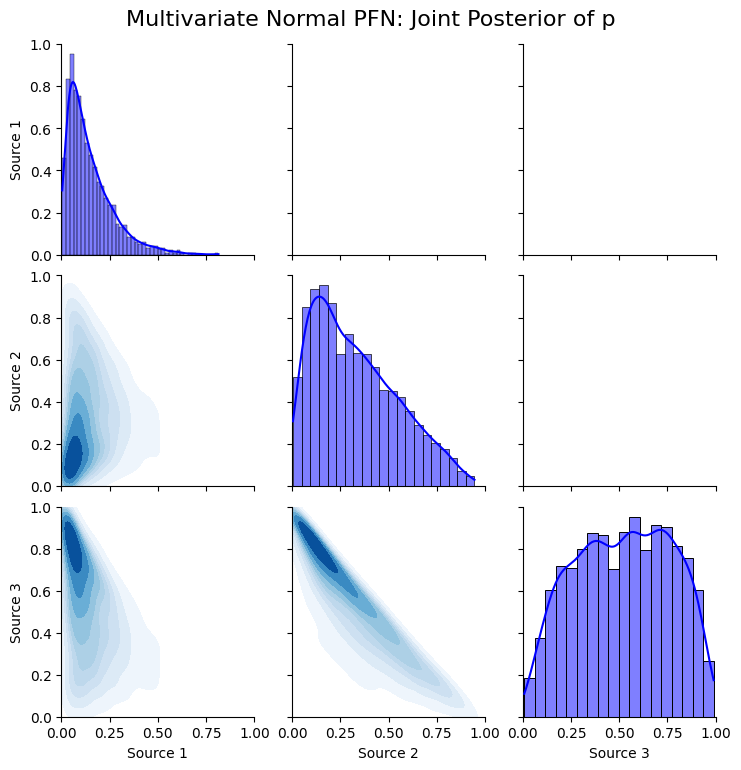

In [6]:
# Cell 5
model.eval()
with torch.no_grad():
    # Simulate one test batch with exactly K=3 sources to easily visualize
    K_test = 3
    ctx, y_pad, target_f, k_mask = simulate_universal_batch(1, device=device)
    
    # Manually overwrite the mask to force K=3 for this test visualization
    ctx[-1][:, :K_test] = 1.0
    ctx[-1][:, K_test:] = 0.0
    k_mask[:, :K_test] = 1.0
    k_mask[:, K_test:] = 0.0
    
    static_context = pack_context(*ctx)
    mean, L = model(static_context, y_pad)
    
    # Clean up L and Mean using the mask to sample cleanly
    mean_clean = mean[0, :K_test]
    L_clean = L[0, :K_test, :K_test]
    
    # Create the predicted Multivariate Normal distribution
    mvn_dist = torch.distributions.MultivariateNormal(loc=mean_clean, scale_tril=L_clean)
    
    # Draw 3000 posterior samples for f
    f_samples = mvn_dist.sample((3000,))
    
    # Transform f to dietary proportions p
    expf = torch.exp(f_samples)
    p_samples = expf / torch.sum(expf, dim=1, keepdim=True)
    
    # Plot using Seaborn
    df_p = pd.DataFrame(p_samples.cpu().numpy(), columns=[f"Source {i+1}" for i in range(K_test)])
    
    print("Generating Joint Posterior Plots for Dietary Proportions (p)...")
    g = sns.PairGrid(df_p, diag_sharey=False)
    g.map_lower(sns.kdeplot, fill=True, cmap="Blues")
    g.map_diag(sns.histplot, kde=True, color="blue")
    
    # Plot formatting
    g.figure.suptitle("Multivariate Normal PFN: Joint Posterior of p", y=1.02, fontsize=16)
    for ax in g.axes.flatten():
        if ax is not None:
            ax.set_xlim([0, 1])
            if ax.get_subplotspec().is_first_col() and not ax.get_subplotspec().is_first_row():
                ax.set_ylim([0, 1])
    plt.show()